# Introduction to PyTorch and Your First Deep Learning Model

In this tutorial you will get familiar with how to train a model using PyTorch.
To start simple the task is a $d$-dimensional linear regression task.
We have already implemented the dataset and an MLP, but you will have to implement the training loop yourself!

### Credits
Bryan Chan, Nov. 2024  

In [ ]:
%matplotlib inline
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
import torch

from typing import List

device = "cuda" if torch.cuda.is_available() else "cpu"

### Construct a multilayer perceptron
This defines the model class (hypothesis/function class).  
**Question:** What class of functions do we get if we have no hidden layers?

In [ ]:
class MLP(torch.nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        num_hidden_units: List[int],
        activation: str = "ReLU",
    ):
        super().__init__()
        self._input_dim = input_dim
        self._output_dim = output_dim
        self._num_hidden_units = num_hidden_units

        layers = []
        for layer_i, (in_dim, out_dim) in enumerate(zip(
            [input_dim, *num_hidden_units],
            [*num_hidden_units, output_dim],
        )):
            layers.append(torch.nn.Linear(in_dim, out_dim))

            if layer_i < len(num_hidden_units):
                layers.append(getattr(torch.nn, activation)())

        self.layers = torch.nn.ModuleList(layers)

    def forward(self, x: torch.tensor):
        for layer in self.layers:
            x = layer(x)
        return x

### Define dataset
This defines a linear-regression task.  
**Questions:**
1. What is the type of machine-learning task?
1. What loss/objective would you use?

In [ ]:
def data_generator(
    num_features,
    batch_size,
    seed,
    noise_mean=0.0,
    noise_variance=1.0,
):
    """
    Generates a linear-regression dataset with some Gaussian noise
    """
    rng = np.random.RandomState(seed)

    # The first num_features entries are weights, the last entry is the bias
    true_w = rng.randn(num_features + 1, 1)

    def data_iterator():
        while True:
            sample_x = rng.uniform(-1.0, 1.0, size=(batch_size, num_features))
            noise = rng.normal(
                loc=noise_mean,
                scale=noise_variance,
                size=(len(sample_x), 1),
            )

            sample_y = sample_x @ true_w[:-1] + true_w[-1] + noise

            yield {
                "input": torch.tensor(sample_x, device=device).float(),
                "target": torch.tensor(sample_y, device=device).float(),
            }
    return true_w, data_iterator

### Define training loop
Here, we will be using minibatch gradient descent to perform gradient updates.
Each batch of samples is represented by a dictionary:
```
batch = {
    "input": torch.Tensor (N, d),
    "target": torch.Tensor (N, 1),
}
```

You have to update the model parameters based on the model predictions vs the batch targets.
To this end, you have to:
1. Compute the model prediction based on the inputs: `model(batch["input"])`
1. Compute the loss using mean-squared error: $$\mathcal{L}(D; \theta) = \frac{1}{2N} \sum_{n=1}^N (f_\theta (x_n) - t_n)^2,$$ where $(x_n, t_n)$ is the $n$'th input-output pair and $N$ is the size of the minibatch.
1. Once you compute the loss, you can obtain the gradient w.r.t. parameters $\theta$ using `loss.backward()` call. Here, you need to call `optimizer.zero_grad()` prior to the `backward()` call because you have to zero-out the gradient from previous iterations---if you don't do this your gradient is accumulated!
1. Take the gradient step using `optimizer.step()`

In [ ]:
def train(dataset, model, optimizer, num_iterations, true_w):
    # For plotting
    fig, axes = plt.subplots(3, 1, figsize=(5, 12), layout="constrained")
    fig.suptitle("Training - $\\theta^*$ = {}".format(true_w))
    fig.supxlabel("Iteration")

    params = {k: [] for k, _ in model.named_parameters()}
    grads = {k: [] for k, _ in model.named_parameters()}
    iterations = []
    losses = []

    # Actual training loop
    for iter_i in range(num_iterations):
        batch = next(dataset)

        loss = torch.tensor(0.0, device=device)

        # ============================================================
        # TODO: Complete this training loop

        # 1. compute the model prediction
        prediction = model(batch["input"])

        # 2. compute the loss
        loss = 0.5 * torch.mean((prediction - batch["target"]) ** 2)

        # 3. zero-out the gradient from previous iterations
        optimizer.zero_grad()

        # 4. compute the gradient
        loss.backward()

        # 5. take the gradient step
        optimizer.step()


        # ============================================================

        # For plotting
        iterations.append(iter_i)
        losses.append(loss.detach().cpu().item())

        # NOTE: To extract the information such as parameter value and its gradient,
        #       you can use model.named_parameters() or model.parameters()
        for k, v in model.named_parameters():
            params[k].append(v.data.detach().clone())
            grads[k].append(v.grad.data.detach())

        for ax in axes:
            ax.clear()

        axes[0].set_title("Loss")
        axes[1].set_title("Parameter")
        axes[2].set_title("Gradient")

        axes[0].plot(iterations, losses)

        for k, _ in model.named_parameters():
            params_v = params[k]
            grads_v = grads[k]
            if k.endswith("weight"):
                params_v = np.array(params_v).transpose((1, 2, 0))
                grads_v = np.array(grads_v).transpose((1, 2, 0))
            elif k.endswith("bias"):
                params_v = np.array(params_v).transpose((1, 0))
                grads_v = np.array(grads_v).transpose((1, 0))
            for idx in np.ndindex(params_v[..., -1].shape):
                axes[1].plot(iterations, params_v[idx], label="{}-{}".format(k, idx))
                axes[2].plot(iterations, grads_v[idx], label="{}-{}".format(k, idx))
        axes[2].legend(loc="upper right")

        display(fig)
        clear_output(wait=True)
        plt.pause(0.01)

tensor(1.2921e-06, grad_fn=<MulBackward0>)


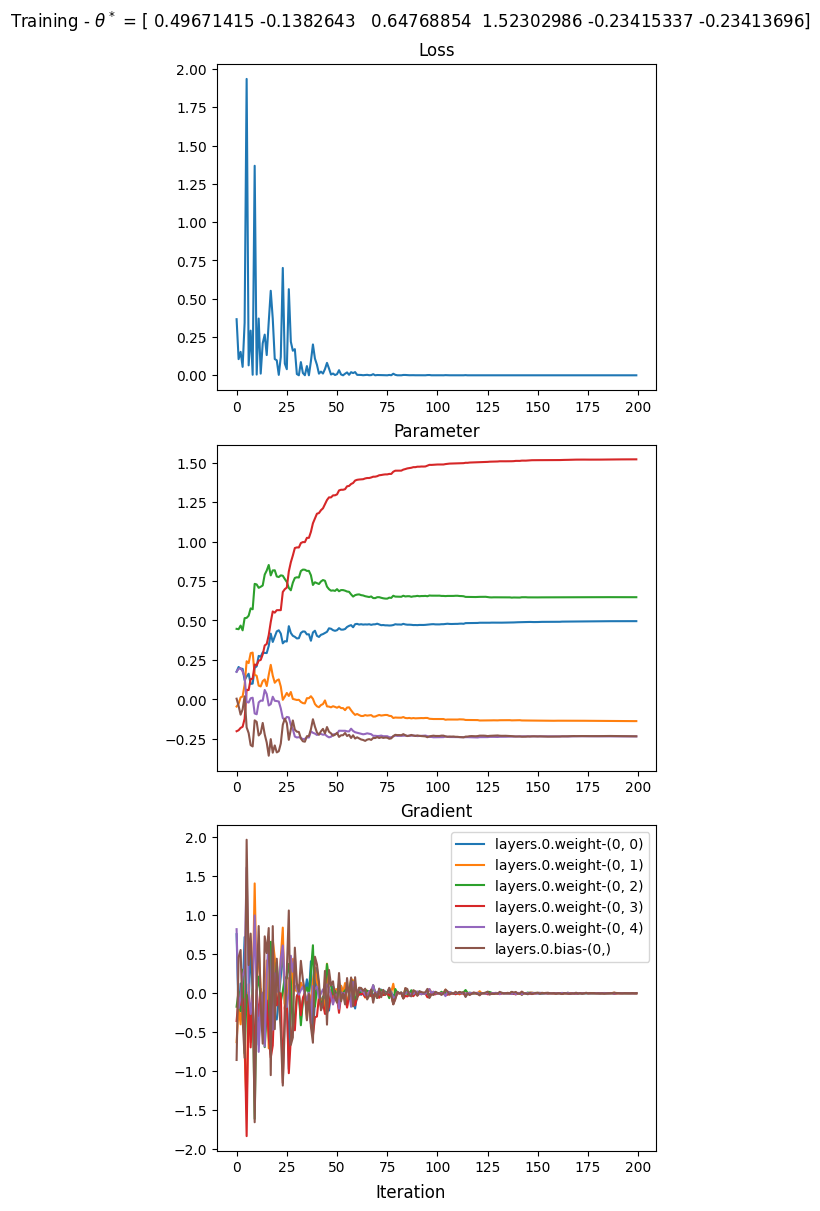

In [ ]:
# For data generation
seed = 42
output_dim = 1 # This is 1 for (scalar) regression

# ============================================================
# TODO: Play around with different hyperparameters
# Training hyperparameters
num_iterations = 200
batch_size = 1

# Instantiate model
input_dim = 5
num_hidden_units = []

# You can use other activations such as Tanh, Sigmoid, GeLU, etc.
activation = "ReLU"

# Instantiate optimizer, can use other optimizer such as Adam, RMSProp, etc.
lr = 1e-1
opt_constructor = torch.optim.SGD
# ============================================================

true_w, dataset = data_generator(
    input_dim,
    batch_size,
    seed,
    noise_mean=0.0,
    noise_variance=0.0,
)
model = MLP(
    input_dim=input_dim,
    output_dim=output_dim,
    num_hidden_units=num_hidden_units,
    activation=activation,
)
model.to(device)

# NOTE: To use L2 regularization, one can use weight_decay in the optimizer.
optimizer = opt_constructor(model.parameters(), lr)

train(dataset(), model, optimizer, num_iterations, true_w.flatten())